<a href="https://colab.research.google.com/github/ansaganakhat/project-1/blob/main/notebook1_rnn_basics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="background: linear-gradient(135deg, #b71c1c 0%, #c62828 50%, #d32f2f 100%); padding: 40px 30px; border-radius: 12px; margin-bottom: 30px;">
  <h1 style="color:#ffffff; font-size:2.2em; font-weight:700; margin:0 0 10px 0;">Зертханалық Жұмыс 1</h1>
  <h2 style="color:#ffcdd2; font-size:1.4em; font-weight:400; margin:0 0 16px 0;">Қайталанатын Нейрондық Желілер — RNN Негіздері</h2>
  <p style="color:#ffebee; font-size:1em; margin:0;">Тізбектермен жұмыс · SimpleRNN · Уақыттық қатар · Мəтін классификациясы</p>
</div>

## Кіріспе

CNN суреттер үшін қаншалықты тиімді болса, **қайталанатын нейрондық желілер (RNN)** тізбектік деректер үшін сондай тиімді. Тіл, дыбыс, уақыттық қатарлар, биологиялық сигналдар — бəрі тізбек. RNN-нің ерекшелігі: ол алдыңғы қадамның күйін (hidden state) келесі қадамға жіберіп, «жадыны» сақтайды.

Стандартты желілер əр үлгіні тəуелсіз өңдейді. RNN болса — «Мен бұл сөзді бұрын берілген сөздер контекстінде оқып отырмын» дейді.

Бұл зертханада уақыттық қатарларды (time series) болжау міндетін шешесіз: синустік толқын деректерін пайдаланып SimpleRNN моделін үйретесіз.

## Оқу Мақсаттары

- RNN-нің жұмыс принципін жəне CNN-нен айырмасын түсіндіре аласыз
- Тізбектік деректерді дайындауды (sliding window) іске асыра аласыз
- SimpleRNN моделін Keras арқылы нөлден жаза аласыз
- `return_sequences` параметрінің мəнін түсінесіз
- Уақыттық қатар болжамын бағалап, визуализациялай аласыз
- Тізбек ұзындығының нəтижеге əсерін эксперимент арқылы байқай аласыз

**Болжалды орындалу уақыты: 60 минут**

## 1-бөлім: Кітапханаларды Импорттау

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import warnings
warnings.filterwarnings('ignore')

In [2]:
# ============================================================
### TODO ###
# TensorFlow нұсқасын шығарыңыз.
# Кездейсоқтықты бекітіңіз: tf.random.set_seed(42), np.random.seed(42)
# ============================================================
print("TensorFlow нұсқасы:",tf.__version__ )
tf.random.set_seed(42)
np.random.seed(42)

TensorFlow нұсқасы: 2.20.0


## 2-бөлім: RNN Жұмыс Принципі

Стандартты (feed-forward) желі мен RNN-нің айырмасын салыстырайық:

| Сипат | Feed-forward | RNN |
|---|---|---|
| Кіріс | Бір вектор | Тізбек (t қадам) |
| Жады | Жоқ | Hidden state арқылы |
| Шығыс | Бір вектор | Əр қадамда немесе соңында |
| Параметрлер | Əр қабатта бөлек | Барлық қадамда **ортақ** |

RNN математикалық формуласы:

```
h_t = tanh(W_h * h_{t-1} + W_x * x_t + b)
```

Мұнда `h_t` — ағымдағы күй (hidden state), `h_{t-1}` — алдыңғы күй, `x_t` — ағымдағы кіріс.

## 3-бөлім: Деректерді Дайындау — Уақыттық Қатар

In [3]:
# Синустік толқын деректерін жасаймыз
# Бұл — RNN үйренуге арналған классикалық тізбектік мысал
t = np.linspace(0, 100, 1000)
signal = np.sin(t) + 0.1 * np.random.randn(len(t))

print("Сигнал ұзындығы:", len(signal))
print("Мəндер диапазоны: [{:.2f}, {:.2f}]".format(signal.min(), signal.max()))

Сигнал ұзындығы: 1000
Мəндер диапазоны: [-1.20, 1.26]


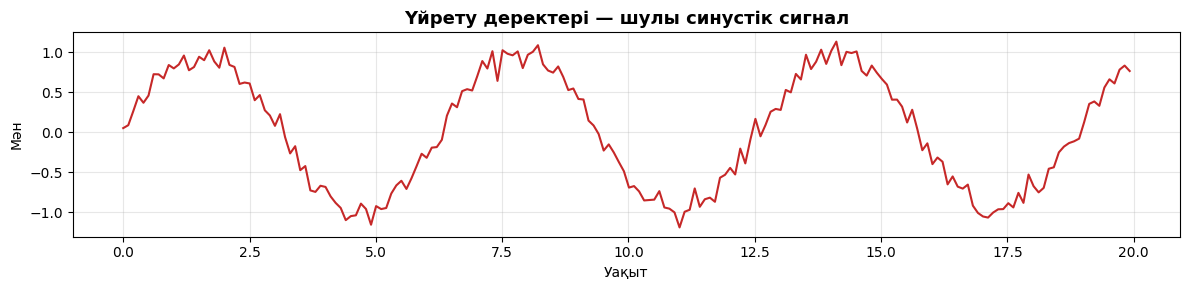

In [4]:
# Сигналдың алғашқы 200 нүктесін бейнелейміз
plt.figure(figsize=(12, 3))
plt.plot(t[:200], signal[:200], linewidth=1.5, color='#c62828')
plt.title('Үйрету деректері — шулы синустік сигнал', fontsize=13, fontweight='bold')
plt.xlabel('Уақыт')
plt.ylabel('Мəн')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Sliding Window əдісі

RNN үшін деректерді тізбек түрінде беру керек. **Sliding window** (жылжымалы терезе) əдісімен:
- Əр үлгі — `window_size` ұзындықтағы тізбек (кіріс)
- Мақсат — тізбектен кейінгі бір нүкте (шығыс)

Мысалы, `window_size=10` болса: `[x₁,x₂,...,x₁₀] → x₁₁`

In [5]:
def create_sequences(data, window_size):
    """
    Уақыттық қатардан тізбекті үлгілер жасайды.

    Параметрлер:
        data        -- 1D массив, уақыттық қатар
        window_size -- кіріс тізбегінің ұзындығы
    Қайтарады:
        X -- (N, window_size, 1) пішімді кіріс тізбектері
        y -- (N,) пішімді мақсат мəндер
    """
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i : i + window_size])
        y.append(data[i + window_size])
    X = np.array(X).reshape(-1, window_size, 1)  # (N, T, features)
    y = np.array(y)
    return X, y

print("Функция анықталды.")

Функция анықталды.


In [6]:
# ============================================================
### TODO ###
# window_size = 20 деп орнатыңыз.
# create_sequences() арқылы X, y жасаңыз.
# X жəне y пішімдерін шығарыңыз.
# ============================================================
WINDOW_SIZE = 20
X, y = create_sequences(signal, WINDOW_SIZE)

print("X пішімі (үлгілер, тізбек, ерекшелік):", X.shape)
print("y пішімі (мақсат):                     ", y.shape)

X пішімі (үлгілер, тізбек, ерекшелік): (980, 20, 1)
y пішімі (мақсат):                      (980,)


In [7]:
# ============================================================
### TODO ###
# Деректерді үйрету (80%) жəне тест (20%) жинақтарына бөліңіз.
# split = int(len(X) * 0.8) арқылы бөлу нүктесін табыңыз.
# X_train, X_test, y_train, y_test айнымалыларын анықтаңыз.
# ============================================================
split = int(len(X) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"Үйрету жинағы:  {X_train.shape}")
print(f"Тест жинағы:    {X_test.shape}")

Үйрету жинағы:  (784, 20, 1)
Тест жинағы:    (196, 20, 1)


## 4-бөлім: SimpleRNN Моделін Құру

`SimpleRNN` қабаты — ең қарапайым қайталанатын қабат. Əр уақыт қадамында hidden state жаңартылады.

Маңызды параметрлер:

| Параметр | Сипаттама |
|---|---|
| `units` | Hidden state өлшемі (нейрондар саны) |
| `return_sequences=True` | Əр қадамның шығысын береді — стекке жасалған RNN үшін |
| `return_sequences=False` | Тек соңғы қадамның шығысын береді — классификация/регрессия үшін |

In [8]:
model = keras.Sequential(name='SimpleRNN_TimeSeries')

In [9]:
# 1-RNN қабат: 64 нейрон, return_sequences=True (екінші RNN үшін)
model.add(layers.SimpleRNN(
    units=64,
    return_sequences=True,
    input_shape=(WINDOW_SIZE, 1),
    name='rnn1'
))
print("1-RNN қабат қосылды:", model.output_shape)

1-RNN қабат қосылды: (None, 20, 64)


In [10]:
# ============================================================
### TODO ###
# 2-RNN қабат қосыңыз:
#   SimpleRNN: units=32, return_sequences=False
#   (соңғы RNN қабатта return_sequences=False болуы керек)
# ============================================================
model.add(layers.SimpleRNN(
    units=32,
    return_sequences=False,
    name='rnn2'
))
print("2-RNN қабат қосылды:", model.output_shape)

2-RNN қабат қосылды: (None, 32)


In [11]:
# ============================================================
### TODO ###
# Шығыс Dense қабатын қосыңыз.
# Регрессия міндеті — бір сан болжаймыз,
# сондықтан units=1, активация жоқ (None немесе 'linear').
# ============================================================
model.add(layers.Dense(1, name='output'))
model.summary()

Model: "SimpleRNN_TimeSeries"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rnn1 (SimpleRNN)                │ (None, 20, 64)         │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn2 (SimpleRNN)                │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,361 (28.75 KB)

 Trainable params: 7,361 (28.75 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# ============================================================
### TODO ###
# Модельді компиляциялаңыз:
#   optimizer='adam'
#   loss='mse'  (Mean Squared Error — регрессия үшін)
#   metrics=['mae']  (Mean Absolute Error)
# ============================================================
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)
print("Компиляция аяқталды.")

Компиляция аяқталды.


## 5-бөлім: Модельді Үйрету

In [13]:
# ============================================================
### TODO ###
# Үйрету гиперпараметрлерін орнатыңыз:
#   EPOCHS=20, BATCH_SIZE=32, VAL_SPLIT=0.1
# ============================================================
EPOCHS     = 20
BATCH_SIZE = 32
VAL_SPLIT  = 0.1

In [14]:
# Early stopping: валидация шығыны жақсармаса үйретуді тоқтатамыз
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

print("Модель үйретілуде...")
history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VAL_SPLIT,
    callbacks=[early_stop],
    verbose=1
)
print("Үйрету аяқталды.")

Модель үйретілуде...
Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.0645 - mae: 0.1827 - val_loss: 0.0178 - val_mae: 0.0954
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0171 - mae: 0.1046 - val_loss: 0.0180 - val_mae: 0.0953
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0134 - mae: 0.0925 - val_loss: 0.0150 - val_mae: 0.0867
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0126 - mae: 0.0897 - val_loss: 0.0133 - val_mae: 0.0822
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0123 - mae: 0.0893 - val_loss: 0.0135 - val_mae: 0.0833
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0122 - mae: 0.0888 - val_loss: 0.0130 - val_mae: 0.0826
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0120 - mae: 0.0882 - val_loss: 0.0125 - val_mae: 0.0815
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0119 - mae: 0.0874 - val_loss: 0.0119 - val_mae: 0.0799
Epoch 9/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13

## 6-бөлім: Нəтижелерді Бағалау

In [15]:
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)
print(f"Тест MSE:  {test_loss:.6f}")
print(f"Тест MAE:  {test_mae:.6f}")

Тест MSE:  0.010638
Тест MAE:  0.083535


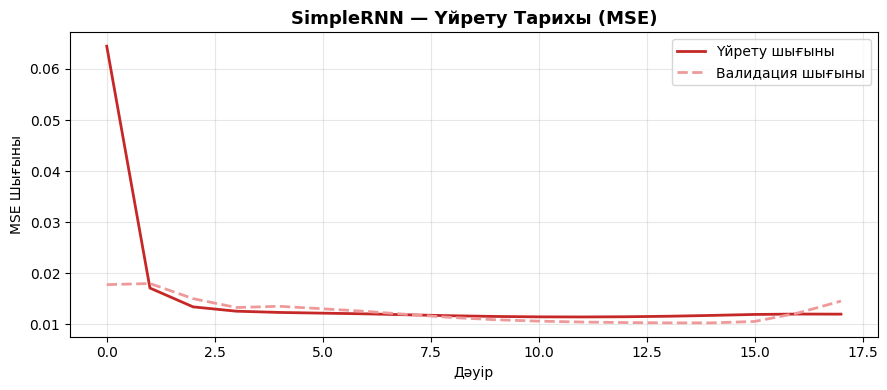

In [16]:
# ============================================================
### TODO ###
# Үйрету жəне валидация шығынын (loss) бір графикте бейнелеңіз.
# history.history['loss'] жəне history.history['val_loss'] пайдаланыңыз.
# ============================================================
plt.figure(figsize=(9, 4))
plt.plot(history.history['loss'],
         label='Үйрету шығыны',
         linewidth=2,
         color='#c62828')

plt.plot(history.history['val_loss'],
         label='Валидация шығыны',
         linewidth=2,
         color='#ef9a9a',
         linestyle='--')
plt.title('SimpleRNN — Үйрету Тарихы (MSE)', fontsize=13, fontweight='bold')
plt.xlabel('Дəуір')
plt.ylabel('MSE Шығыны')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7-бөлім: Болжамдарды Визуализациялау

In [17]:
# ============================================================
### TODO ###
# model.predict() арқылы тест жинағындағы болжамдарды алыңыз.
# Нəтижені flatten() арқылы 1D массивке айналдырыңыз.
# ============================================================
y_pred = model.predict(X_test, verbose=0).flatten()
print("Болжамдар пішімі:", y_pred.shape)

Болжамдар пішімі: (196,)


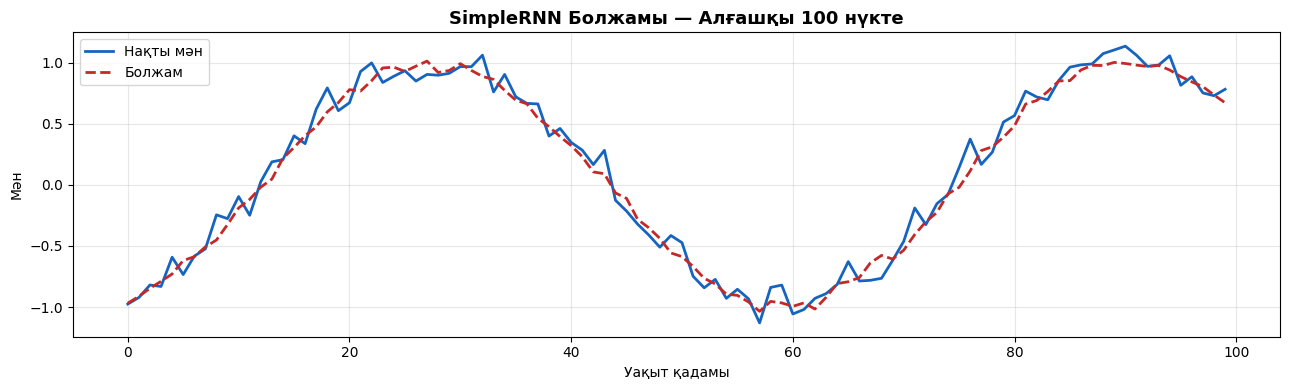

In [18]:
# Нақты мəндер мен болжамдарды салыстырамыз
plt.figure(figsize=(13, 4))
plt.plot(y_test[:100],  label='Нақты мəн',  linewidth=2, color='#1565C0')
plt.plot(y_pred[:100],  label='Болжам',      linewidth=2, color='#c62828', linestyle='--')
plt.title('SimpleRNN Болжамы — Алғашқы 100 нүкте', fontsize=13, fontweight='bold')
plt.xlabel('Уақыт қадамы')
plt.ylabel('Мəн')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

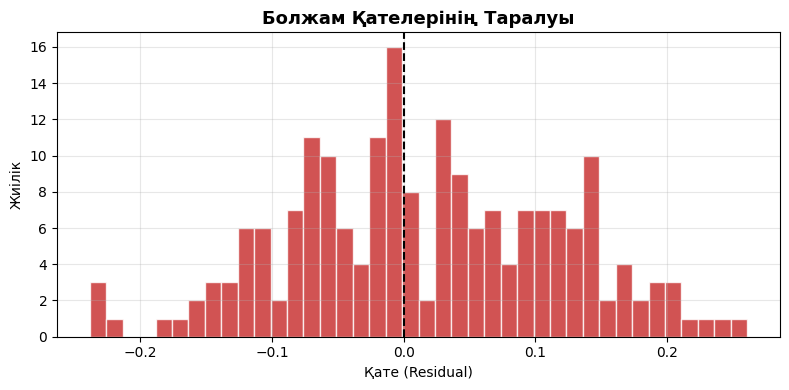

Орташа қате:           0.016506
Стандартты ауытқу:     0.101813


In [22]:
# ============================================================
### TODO ###
# Болжам қателерін (residuals) есептеңіз: y_test - y_pred
# Қателердің гистограммасын бейнелеңіз (bins=40).
# Орташа қатені (mean) жəне стандартты ауытқуды (std) шығарыңыз.
# ============================================================
residuals = y_test - y_pred

plt.figure(figsize=(8, 4))
plt.hist(residuals,
         bins=40,
         color='#c62828',
         edgecolor='white',
         alpha=0.8)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1.5)
plt.title('Болжам Қателерінің Таралуы', fontsize=13, fontweight='bold')
plt.xlabel('Қате (Residual)')
plt.ylabel('Жиілік')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Орташа қате:           {residuals.mean():.6f}")
print(f"Стандартты ауытқу:     {residuals.std():.6f}")

## 8-бөлім: return_sequences Параметрін Зерттеу

`return_sequences=True` болса — RNN əр уақыт қадамының шығысын береді, пішімі `(batch, timesteps, units)`. Бұл параметр стекке жасалған RNN-де (RNN үстіне RNN) міндетті түрде қолданылады.

In [23]:
# return_sequences=True жəне False нəтижелерін салыстырамыз
rnn_true  = layers.SimpleRNN(8, return_sequences=True,  input_shape=(WINDOW_SIZE, 1))
rnn_false = layers.SimpleRNN(8, return_sequences=False, input_shape=(WINDOW_SIZE, 1))

sample_input = X_train[:1]  # (1, WINDOW_SIZE, 1)
out_true  = rnn_true(sample_input)
out_false = rnn_false(sample_input)

print("return_sequences=True  шығыс пішімі:", out_true.shape)
print("return_sequences=False шығыс пішімі:", out_false.shape)

return_sequences=True  шығыс пішімі: (1, 20, 8)
return_sequences=False шығыс пішімі: (1, 8)


In [24]:
# ============================================================
### TODO ###
# return_sequences=True шығысынан:
#   - алғашқы уақыт қадамының шығысын (out_true[0, 0, :]) шығарыңыз
#   - соңғы уақыт қадамының шығысын (out_true[0, -1, :]) шығарыңыз
#   - out_false[0] мəнімен соңғы қадам мəнін салыстырыңыз
# Олар бірдей ме?
# ============================================================
first_step = out_true[0, 0, :].numpy()
last_step  = out_true[0, -1, :].numpy()
seq_false  = out_false[0].numpy()

print("Бірінші қадам:", first_step.round(4))
print("Соңғы қадам:  ", last_step.round(4))
print("False шығысы: ", seq_false.round(4))
print("\nСоңғы қадам == False шығысы:", np.allclose(last_step, seq_false, atol=1e-5))

Бірінші қадам: [ 0.0378  0.0093  0.0055 -0.0266  0.0041  0.0232 -0.0288 -0.0275]
Соңғы қадам:   [ 0.32   -0.576   0.3157 -0.7879 -0.095   0.8597 -0.0076 -0.5201]
False шығысы:  [ 0.4225  0.0315 -0.3842  0.016  -0.0987 -0.3585  0.8031 -0.3832]

Соңғы қадам == False шығысы: False


## 9-бөлім: Window Size Эксперименті

In [25]:
def build_and_train_rnn(window_size, epochs=15):
    """Берілген терезе өлшеміне арналған RNN үйретіп нəтиже қайтарады."""
    X_w, y_w = create_sequences(signal, window_size)
    split_w  = int(len(X_w) * 0.8)
    Xtr, Xte = X_w[:split_w], X_w[split_w:]
    ytr, yte = y_w[:split_w], y_w[split_w:]

    m = keras.Sequential([
        layers.SimpleRNN(32, input_shape=(window_size, 1)),
        layers.Dense(1)
    ])
    m.compile(optimizer='adam', loss='mse', metrics=['mae'])
    m.fit(Xtr, ytr, epochs=epochs, batch_size=32,
          validation_split=0.1, verbose=0)
    _, mae = m.evaluate(Xte, yte, verbose=0)
    return mae

print("Функция анықталды.")

Функция анықталды.


In [26]:
# ============================================================
### TODO ###
# Үш түрлі терезе өлшемін сынаңыз: [10, 20, 40]
# window_sizes тізімін толтырыңыз.
# ============================================================
window_sizes = [10, 20, 40]
ws_results   = {}

for ws in window_sizes:
    print(f"Window={ws} үйретілуде...")
    mae = build_and_train_rnn(window_size=ws)
    ws_results[ws] = mae
    print(f"  MAE: {mae:.6f}")

Window=10 үйретілуде...
  MAE: 0.088485
Window=20 үйретілуде...
  MAE: 0.101071
Window=40 үйретілуде...
  MAE: 0.082562


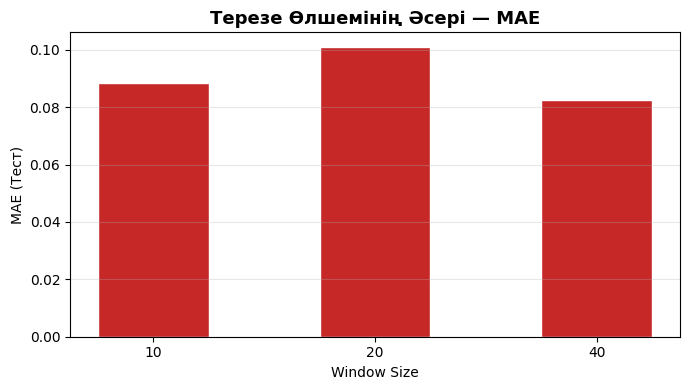

Үздік терезе өлшемі: 40  (MAE=0.082562)


In [27]:
# ============================================================
### TODO ###
# ws_results нəтижелерін bar chart-та бейнелеңіз.
# X осі — window_size мəндері, Y осі — MAE.
# ============================================================

plt.figure(figsize=(7, 4))
plt.bar([str(ws) for ws in window_sizes],
        [ws_results[ws] for ws in window_sizes],
        color='#c62828', edgecolor='white', width=0.5)
plt.title('Терезе Өлшемінің Əсері — MAE', fontsize=13, fontweight='bold')
plt.xlabel('Window Size')
plt.ylabel('MAE (Тест)')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

best_ws = min(ws_results, key=ws_results.get)
print(f"Үздік терезе өлшемі: {best_ws}  (MAE={ws_results[best_ws]:.6f})")

## 10-бөлім: Авторегрессиялық Болжам

Авторегрессиялық болжамда модель өзінің алдыңғы болжамдарын кіріс ретінде пайдаланып көп қадам болжам жасайды. Бұл нақты жобаларда маңызды тəсіл.

In [31]:
def autoregressive_forecast(model, seed_sequence, n_steps):
    """
    Авторегрессиялық болжам жасайды.
    seed_sequence: бастапқы тізбек, ұзындығы WINDOW_SIZE
    n_steps: болжам қадамдарының саны
    """
    current_seq = seed_sequence.copy().reshape(1, WINDOW_SIZE, 1)
    forecast = []

    for _ in range(n_steps):
        pred = model.predict(current_seq, verbose=0)[0, 0]
        forecast.append(pred)

        current_seq = np.roll(current_seq, -1, axis=1)
        current_seq[0, -1, 0] = pred

    return np.array(forecast)

print("Авторегрессиялық функция анықталды.")

Авторегрессиялық функция анықталды.


In [32]:
# ============================================================
### TODO ###
# Тест жинағының алғашқы WINDOW_SIZE нүктесін seed ретінде пайдаланыңыз.
# 50 қадамға авторегрессиялық болжам жасаңыз.
# ============================================================
seed_seq = X_test[0, :, 0]    # (WINDOW_SIZE,) пішімді тізбек
forecast = autoregressive_forecast(
    model,
    seed_seq,
    n_steps=50
)

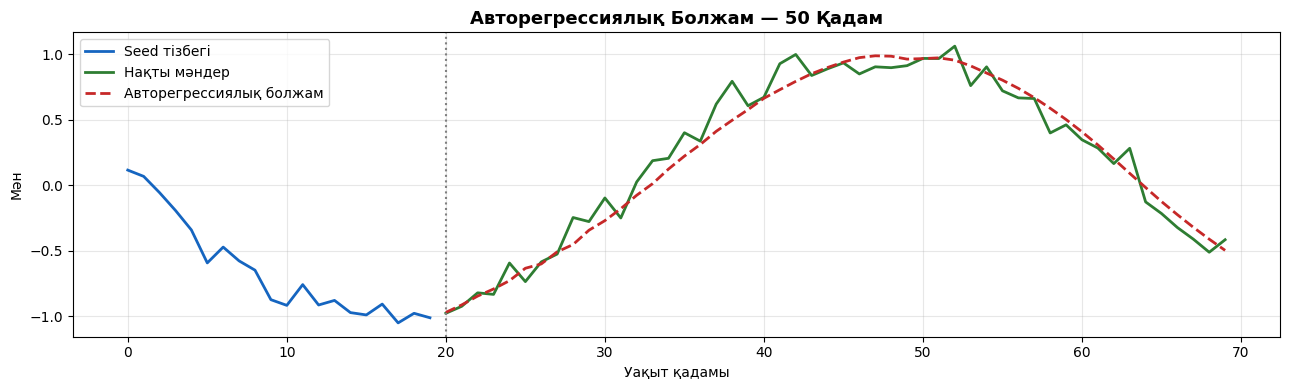

In [33]:
# Болжамды нақты мəндермен салыстырамыз
plt.figure(figsize=(13, 4))

# Бастапқы тізбек (seed)
plt.plot(range(WINDOW_SIZE), seed_seq,
         label='Seed тізбегі', color='#1565C0', linewidth=2)

# Нақты жалғасы
actual_next = y_test[:50]
plt.plot(range(WINDOW_SIZE, WINDOW_SIZE + 50), actual_next,
         label='Нақты мəндер', color='#2e7d32', linewidth=2)

# Авторегрессиялық болжам
plt.plot(range(WINDOW_SIZE, WINDOW_SIZE + 50), forecast,
         label='Авторегрессиялық болжам', color='#c62828', linewidth=2, linestyle='--')

plt.axvline(x=WINDOW_SIZE, color='gray', linestyle=':', linewidth=1.5)
plt.title('Авторегрессиялық Болжам — 50 Қадам', fontsize=13, fontweight='bold')
plt.xlabel('Уақыт қадамы')
plt.ylabel('Мəн')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 11-бөлім: Hidden State Динамикасы

In [44]:
## 11-бөлім: Hidden State Динамикасы

# Алғашқы RNN қабатын аламыз
rnn1_layer = model.get_layer('rnn1')

# Алғашқы 50 тест үлгісін өткіземіз
hidden_states = rnn1_layer(X_test[:50])

# Tensor -> NumPy
hidden_states = hidden_states.numpy()

print("Hidden state пішімі:", hidden_states.shape)



Hidden state пішімі: (50, 20, 64)


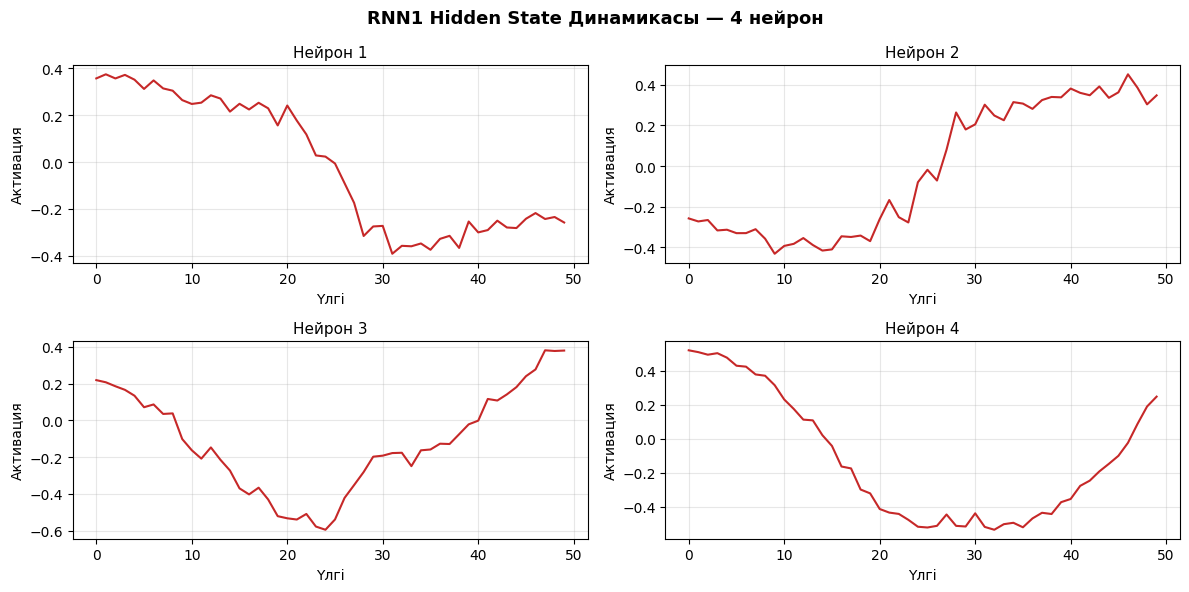

In [45]:
# ============================================================
### TODO ###
# hidden_states-тің алғашқы 4 нейронының динамикасын
# 2×2 торда бейнелеңіз.
# hidden_states пішімі: (50, WINDOW_SIZE, 64)
# hidden_states[:, -1, i] — i-ші нейронның соңғы қадамдағы күйі.
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 6))
fig.suptitle('RNN1 Hidden State Динамикасы — 4 нейрон', fontsize=13, fontweight='bold')

for i, ax in enumerate(axes.flatten()):
    ax.plot(hidden_states[:, -1, i], linewidth=1.5, color='#c62828')
    ax.set_title(f'Нейрон {i+1}', fontsize=11)
    ax.set_xlabel('Үлгі')
    ax.set_ylabel('Активация')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 12-бөлім: Many-to-One жəне Many-to-Many

RNN əртүрлі режимде жұмыс жасайды:

| Режим | Сипаттама | Мысал |
|---|---|---|
| **Many-to-One** | T кіріс → 1 шығыс | Мəтін классификациясы |
| **Many-to-Many** | T кіріс → T шығыс | Аударма, тег белгілеу |
| **One-to-Many** | 1 кіріс → T шығыс | Сурет тақырыбы (captioning) |

In [46]:
# Many-to-Many модель: əр уақыт қадамында болжам жасайды
# return_sequences=True + TimeDistributed(Dense) пайдаланамыз

m2m_model = keras.Sequential(name='Many_to_Many', layers=[
    layers.SimpleRNN(32, return_sequences=True, input_shape=(WINDOW_SIZE, 1)),
    layers.TimeDistributed(layers.Dense(1))   # əр қадамда 1 шығыс
])

m2m_model.summary()

Model: "Many_to_Many"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_5 (SimpleRNN)        │ (None, 20, 32)         │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 20, 1)          │            33 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,121 (4.38 KB)

 Trainable params: 1,121 (4.38 KB)

 Non-trainable params: 0 (0.00 B)

In [47]:
# ============================================================
### TODO ###
# Many-to-Many үшін мақсат деректерін дайындаңыз.
# X_m2m — бұрынғы X_train (кіріс тізбектер)
# y_m2m — əр кіріс тізбегін бір қадам оңға жылжытқан тізбек
#   яғни: X_train[:, 1:, :] мен y_train-ді біріктіру арқылы
#   пішімі (N, WINDOW_SIZE, 1) болу керек.
#
# Ескерту: y_m2m = np.concatenate(
#     [X_train[:, 1:, :], y_train.reshape(-1,1,1)], axis=1)
# ============================================================
y_m2m = np.concatenate(
    [X_train[:, 1:, :],
     y_train.reshape(-1, 1, 1)],
    axis=1
)
print("Many-to-Many мақсат пішімі:", y_m2m.shape)

m2m_model.compile(optimizer='adam', loss='mse')
m2m_model.fit(X_train, y_m2m, epochs=5, batch_size=32, verbose=0)
print("Many-to-Many үйрету аяқталды.")

Many-to-Many мақсат пішімі: (784, 20, 1)
Many-to-Many үйрету аяқталды.


## 13-бөлім: Рефлексиялық Сұрақтар

**Сұрақ 1.** RNN-де барлық уақыт қадамдарында бір ғана салмақтар жиынтығы қолданылады. Бұл не үшін тиімді?

> RNN-де барлық уақыт қадамдары бірдей салмақтарды қолданады. Бұл параметрлер санын азайтады, модельді тиімді етеді және әртүрлі ұзындықтағы тізбектерді өңдеуге мүмкіндік береді.

**Сұрақ 2.** `return_sequences=True` мен `False` айырмасын өз сөзіңізбен түсіндіріңіз. Стекке жасалған RNN-де неліктен `True` қолданылады?

> return_sequences=True болғанда RNN әр уақыт қадамының шығысын қайтарады, ал False болғанда тек соңғы қадамның шығысын қайтарады. Бірнеше RNN қабатын бірінің үстіне бірін орналастырғанда келесі қабатқа толық тізбек қажет болғандықтан True қолданылады.

**Сұрақ 3.** Window size эксперименті нені көрсетті? Үлкен терезе əрқашан жақсы нəтиже бере ме?

> Эксперимент терезе өлшемінің модель сапасына әсер ететінін көрсетті. Үлкен терезе көбірек контекст береді, бірақ әрқашан жақсы нәтиже бермейді. Өте үлкен терезе артық ақпарат пен артық үйренуге әкелуі мүмкін.

**Сұрақ 4.** Авторегрессиялық болжам 50 қадам ілгері барған сайын дəлдік азайды ма? Неліктен?

> Иә, әдетте дәлдік төмендейді. Себебі әр жаңа қадамда модель өз болжамын қайта пайдаланады және қателер жинақталып көбейеді.

**Сұрақ 5.** SimpleRNN-нің негізгі əлсіздігі — ұзын тізбектерде алғашқы ақпарат жоғалады. Бұл проблема не деп аталады?

> Бұл мәселе Vanishing Gradient Problem (градиенттің жоғалуы) деп аталады. Ұзын тізбектерде ертеректегі ақпаратты сақтау қиындайды.

## Қорытынды

Осы зертханада сіз тізбектік деректерді sliding window əдісімен дайындауды, SimpleRNN моделін нөлден жазуды, үйрету тарихын жəне болжамдарды визуализациялауды, return_sequences параметрінің əсерін байқауды, авторегрессиялық болжам жасауды, жəне window size гиперпараметрін эксперимент арқылы зерттеуді іске асырдыңыз.

<div style="background-color:#ffebee; border-left:5px solid #c62828; padding:12px 16px; border-radius:6px; margin-top:16px;">
<strong>Келесі қадам:</strong> Зертханалық Жұмыс 2 — LSTM архитектурасы жəне ұзақ тəуелділіктер проблемасы.
</div>